# Analysis for Unperturbed Method

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing_extensions import *
from sentence_transformers import SentenceTransformer

In [3]:
class MlpMapper(nn.Module):
	def __init__(self, input_dim: int, intermediate_dims: List, output_dim: int, use_bias: bool = True, logit_scale: float = 100.0):
		super().__init__()
		self.input_dim = input_dim
		self.intermediate_dims = intermediate_dims # list of ints
		self.output_dim = output_dim
		self.num_layers = len(intermediate_dims) + 1

		self.layers = []
		current_dim = input_dim
		next_dims = intermediate_dims + [output_dim]

		if logit_scale < 0:
			self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
		else:
			self.logit_scale = torch.tensor(np.log(logit_scale))

		for i in range(self.num_layers):
			self.layers.append(nn.Linear(current_dim, next_dims[i], bias=use_bias))
			current_dim = next_dims[i]

			if i != self.num_layers - 1:
				self.layers.append(nn.GELU())

		self.layers = nn.Sequential(*self.layers)

	def forward(self, x):
		x = self.layers(x)
		return F.normalize(x, dim=-1)


## Cifar-10

In [5]:
image_embeddings = np.load("embeddings/cifar10/radius_analysis_embeddings.npy", allow_pickle=True)
image_embeddings = image_embeddings.item()

tmp_te = SentenceTransformer("sentence-t5-base")
class_embeddings = tmp_te.encode(["a photo of a airplane"])

tmp_mapper = MlpMapper(768, [], 384)
ep0_embedding = tmp_mapper(torch.from_numpy(class_embeddings))

tmp_mapper.load_state_dict(torch.load("embeddings/ckpt_1_1.pt", map_location=torch.device("cpu"))["model"])
ep1_embedding = tmp_mapper(torch.from_numpy(class_embeddings))
# class_embeddings = np.load("embeddings/cifar10/class_embeddings_over_epochs.npy", allow_pickle=True)
# class_embeddings = class_embeddings.item()


/var/folders/76/k9dkfmf92q19jtdmr7qd_nh00000gn/T/ipykernel_56521/4018533642.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tmp_mapper.load_state_dict(torch.load("embed

In [6]:
all_image_embeddings = np.concatenate([
    v for v in image_embeddings["image"].values()
], axis=0)

# all_text_embeddings = np.concatenate([
#     v for v in class_embeddings.values()
# ], axis=0)
# print(all_text_embeddings.shape)


In [8]:
class_index = 0

pca = PCA(n_components=2)
pca.fit(all_image_embeddings)
image_embeddings_2d = pca.transform(image_embeddings["image"][class_index])
ep0_embedding_2d = pca.transform(ep0_embedding.detach().cpu().numpy())
ep1_embedding_2d = pca.transform(ep1_embedding.detach().cpu().numpy())

In [9]:
image_centroid = pca.transform(image_embeddings["image"][class_index].mean(axis=0).reshape(1, -1))
image_centroid

array([[0.21023571, 0.0955553 ]], dtype=float32)

### Un-normalized, Euclidean

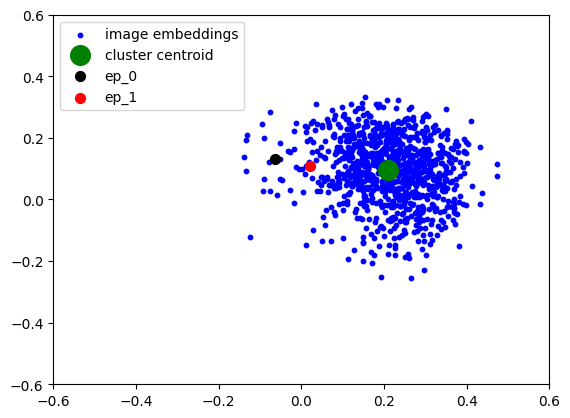

In [10]:
plt.scatter(image_embeddings_2d[:, 0], image_embeddings_2d[:, 1], label="image embeddings", c="blue", s=10)
plt.scatter(image_centroid[:, 0], image_centroid[:, 1], c="green", s=200, label="cluster centroid")

plt.scatter(ep0_embedding_2d[0, 0], ep0_embedding_2d[0, 1], label=f"ep_0", c="black", s=50)
plt.scatter(ep1_embedding_2d[0, 0], ep1_embedding_2d[0, 1], label=f"ep_1", c="red", s=50)
plt.xlim([-0.6, 0.6])
plt.ylim([-0.6, 0.6])
plt.legend()
plt.show()

### Normalized, Cosine

In [11]:
# Normalize all_text_embeddings_2d
all_text_embeddings_2d = ep1_embedding_2d / np.linalg.norm(ep1_embedding_2d, axis=-1, keepdims=True)

# Normalize image_embeddings_2d
image_embeddings_2d = image_embeddings_2d / np.linalg.norm(image_embeddings_2d, axis=-1, keepdims=True)

image_centroid /= np.linalg.norm(image_centroid, axis=-1, keepdims=True)
ep0_embedding_2d /= np.linalg.norm(ep0_embedding_2d, axis=-1, keepdims=True)

In [12]:
print(image_centroid, ep0_embedding_2d)

[[0.9103769 0.41378  ]] [[-0.44165808  0.8971834 ]]


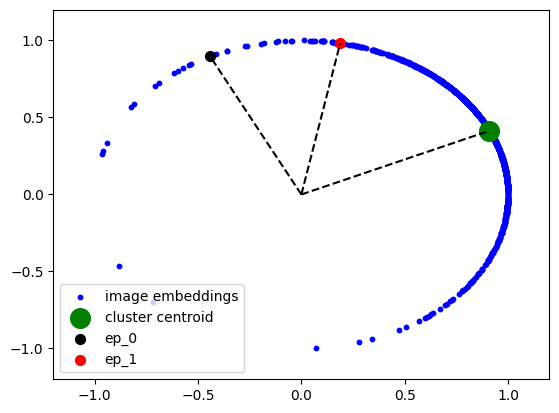

In [13]:
plt.scatter(image_embeddings_2d[:, 0], image_embeddings_2d[:, 1], label="image embeddings", c="blue", s=10)
plt.scatter(image_centroid[:, 0], image_centroid[:, 1], c="green", s=200, label="cluster centroid")
plt.plot([0.0, image_centroid[:, 0].item()], [0.0, image_centroid[:, 1].item()], c="black", linestyle="--")

j = 0
plt.scatter(ep0_embedding_2d[0, 0], ep0_embedding_2d[0, 1], label=f"ep_0", c="black", s=50)
plt.plot([0.0, ep0_embedding_2d[j, 0]], [0.0, ep0_embedding_2d[j, 1]], c="black", linestyle="--")

plt.scatter(all_text_embeddings_2d[j, 0], all_text_embeddings_2d[j, 1], label=f"ep_1", c="red", s=50)
plt.plot([0.0, all_text_embeddings_2d[j, 0]], [0.0, all_text_embeddings_2d[j, 1]], c="black", linestyle="--")

plt.xlim([-1.2, 1.2])
plt.ylim([-1.2, 1.2])
plt.legend()
plt.show()

## ImageNet1k

In [16]:
image_embeddings = np.load("embeddings/imagenet/radius_analysis_embeddings.npy", allow_pickle=True)
image_embeddings = image_embeddings.item()

tmp_te = SentenceTransformer("sentence-t5-base")
class_embeddings = tmp_te.encode(["a photo of a tench"])

tmp_mapper = MlpMapper(768, [], 384)
ep0_embedding = tmp_mapper(torch.from_numpy(class_embeddings))

tmp_mapper.load_state_dict(torch.load("embeddings/ckpt_1_1.pt", map_location=torch.device("cpu"))["model"])
ep1_embedding = tmp_mapper(torch.from_numpy(class_embeddings))

/var/folders/76/k9dkfmf92q19jtdmr7qd_nh00000gn/T/ipykernel_56521/1552173974.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tmp_mapper.load_state_dict(torch.load("embed

In [17]:
all_image_embeddings = np.concatenate([
    v for v in image_embeddings["image"].values()
], axis=0)



In [20]:
class_index = 0

pca = PCA(n_components=2)
pca.fit(all_image_embeddings)
image_embeddings_2d = pca.transform(image_embeddings["image"][class_index])
ep0_embedding_2d = pca.transform(ep0_embedding.detach().cpu().numpy())
ep1_embedding_2d = pca.transform(ep1_embedding.detach().cpu().numpy())

In [21]:
image_centroid = pca.transform(image_embeddings["image"][class_index].mean(axis=0).reshape(1, -1))
image_centroid

array([[-0.07874291, -0.04038155]], dtype=float32)

### Un-normalised, Euclidean

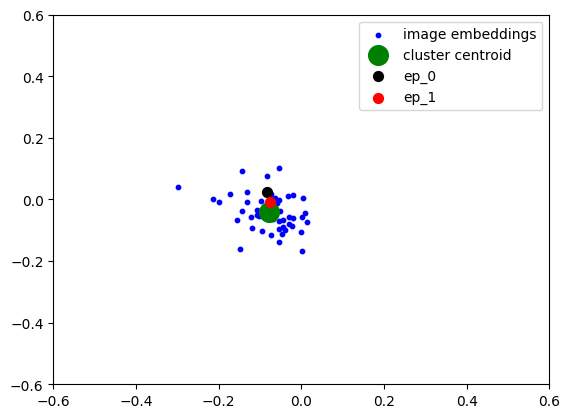

In [23]:
plt.scatter(image_embeddings_2d[:, 0], image_embeddings_2d[:, 1], label="image embeddings", c="blue", s=10)
plt.scatter(image_centroid[:, 0], image_centroid[:, 1], c="green", s=200, label="cluster centroid")

plt.scatter(ep0_embedding_2d[0, 0], ep0_embedding_2d[0, 1], label=f"ep_0", c="black", s=50)
plt.scatter(ep1_embedding_2d[0, 0], ep1_embedding_2d[0, 1], label=f"ep_1", c="red", s=50)
plt.xlim([-0.6, 0.6])
plt.ylim([-0.6, 0.6])
plt.legend()
plt.show()

### Normalised, Cosine

In [24]:
# Normalize all_text_embeddings_2d
all_text_embeddings_2d = all_text_embeddings_2d / np.linalg.norm(all_text_embeddings_2d, axis=-1, keepdims=True)

# Normalize image_embeddings_2d
image_embeddings_2d = image_embeddings_2d / np.linalg.norm(image_embeddings_2d, axis=-1, keepdims=True)

image_centroid /= np.linalg.norm(image_centroid, axis=-1, keepdims=True)
ep0_embedding_2d /= np.linalg.norm(ep0_embedding_2d, axis=-1, keepdims=True)
ep1_embedding_2d /= np.linalg.norm(ep1_embedding_2d, axis=-1, keepdims=True)

In [25]:
print(image_centroid, ep0_embedding_2d)

[[-0.88981485 -0.45632175]] [[-0.961548    0.27463695]]


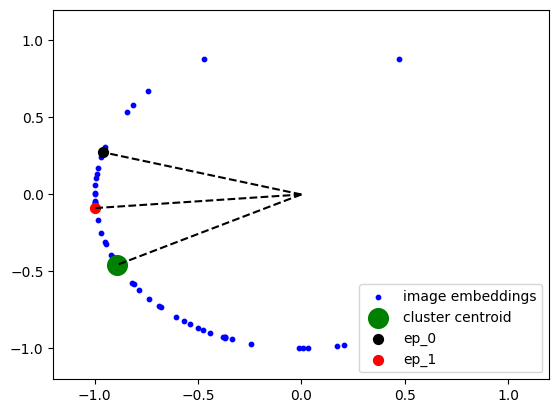

In [26]:
plt.scatter(image_embeddings_2d[:, 0], image_embeddings_2d[:, 1], label="image embeddings", c="blue", s=10)
plt.scatter(image_centroid[:, 0], image_centroid[:, 1], c="green", s=200, label="cluster centroid")
plt.plot([0.0, image_centroid[:, 0].item()], [0.0, image_centroid[:, 1].item()], c="black", linestyle="--")

j = 0
plt.scatter(ep0_embedding_2d[0, 0], ep0_embedding_2d[0, 1], label=f"ep_0", c="black", s=50)
plt.plot([0.0, ep0_embedding_2d[j, 0]], [0.0, ep0_embedding_2d[j, 1]], c="black", linestyle="--")

plt.scatter(ep1_embedding_2d[j, 0], ep1_embedding_2d[j, 1], label=f"ep_1", c="red", s=50)
plt.plot([0.0, ep1_embedding_2d[j, 0]], [0.0, ep1_embedding_2d[j, 1]], c="black", linestyle="--")

plt.xlim([-1.2, 1.2])
plt.ylim([-1.2, 1.2])
plt.legend()
plt.show()